# 04 - Análisis Bivariado

**Pregunta de negocio:** ¿Qué variables están relacionadas?

## Objetivos
- Scatter plots de relaciones clave
- Pair plot de variables numéricas
- Box plots agrupados (consumo por tipo × estilo)
- Matriz de correlación completa

## Teoría
- **Scatter plot**: relación entre dos numéricas. Buscar: tendencia, clusters, outliers
- **Pair plot**: todos los pares de variables — vista panorámica rápida
- **Correlación de Pearson**: fuerza de relación lineal (-1 a +1). No implica causalidad
- **Box plot agrupado**: distribución segmentada por dos categóricas

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
merged = pd.read_csv(os.path.join(project_root, "data/processed/vehicle_survey_merged.csv"))

# Filtrar los que tienen encuesta
if 'has_survey' in merged.columns:
    data = merged[merged['has_survey'] == True].copy()
else:
    data = merged.copy()

print(f"Dataset: {data.shape}")
print(f"Columnas numéricas: {list(data.select_dtypes(include=[np.number]).columns)}")

Dataset: (50, 35)
Columnas numéricas: ['n_registros', 'n_viajes', 'speed_mean', 'speed_max', 'speed_std', 'consumption_mean', 'consumption_total', 'battery_soc_mean', 'battery_temp_max', 'motor_rpm_mean', 'motor_power_mean', 'harsh_braking_count', 'estimated_km', 'model_year', 'motor_power_kw', 'max_speed_kmh', 'weight_kg', 'battery_capacity_kwh', 'tank_capacity_l', 'base_consumption_city', 'base_consumption_highway', 'co2_emissions_gkm', 'age', 'satisfaction_score', 'km_driven']


## 1. Scatter plots de relaciones clave

/home/danielmf31/Documentos/Documentos_Trabajo/Ingenieria/Programacion/VSCode/Proyectos_personales/Ciencia_Datos/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/danielmf31/Documentos/Documentos_Trabajo/Ingenieria/Programacion/VSCode/Proyectos_personales/Ciencia_Datos/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


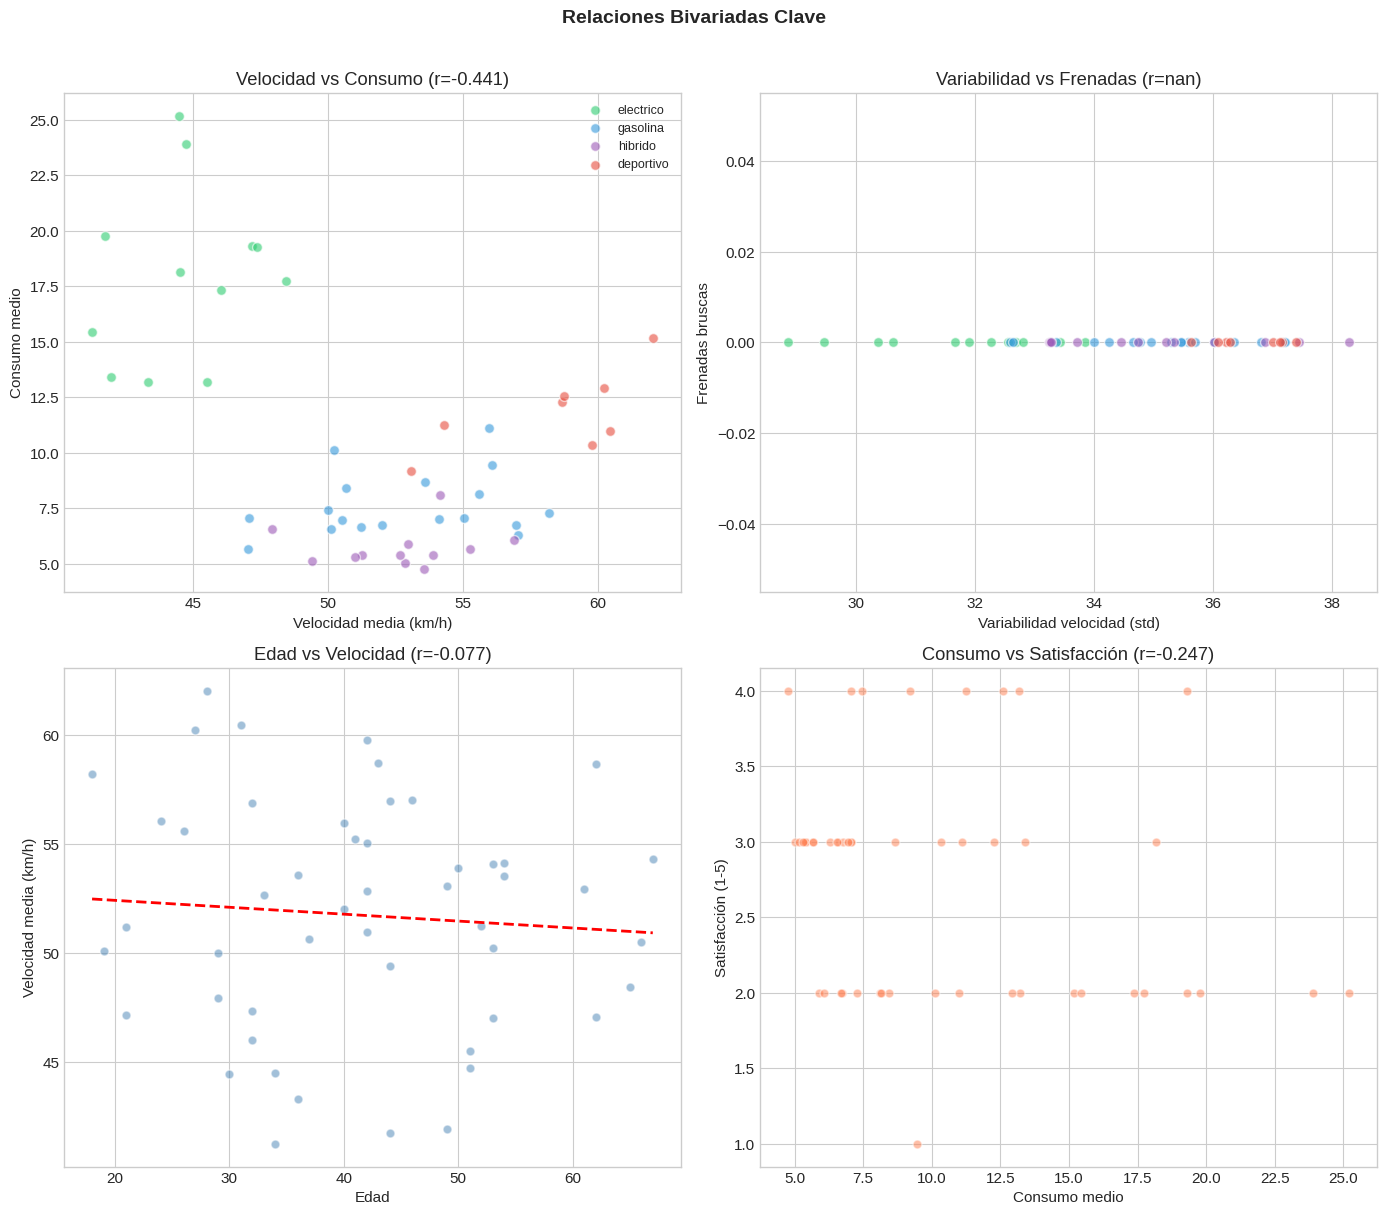

In [2]:
vtype_colors = {'electrico': '#2ecc71', 'gasolina': '#3498db', 'hibrido': '#9b59b6', 'deportivo': '#e74c3c'}

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Velocidad vs Consumo
for vtype, color in vtype_colors.items():
    subset = data[data['vehicle_type'] == vtype]
    axes[0, 0].scatter(subset['speed_mean'], subset['consumption_mean'],
                       alpha=0.6, s=50, color=color, edgecolors='white', label=vtype)
r = data['speed_mean'].corr(data['consumption_mean'])
axes[0, 0].set_xlabel('Velocidad media (km/h)')
axes[0, 0].set_ylabel('Consumo medio')
axes[0, 0].set_title(f'Velocidad vs Consumo (r={r:.3f})')
axes[0, 0].legend(fontsize=9)

# 2. Velocidad vs Frenadas bruscas
for vtype, color in vtype_colors.items():
    subset = data[data['vehicle_type'] == vtype]
    axes[0, 1].scatter(subset['speed_std'], subset['harsh_braking_count'],
                       alpha=0.6, s=50, color=color, edgecolors='white', label=vtype)
r2 = data['speed_std'].corr(data['harsh_braking_count'])
axes[0, 1].set_xlabel('Variabilidad velocidad (std)')
axes[0, 1].set_ylabel('Frenadas bruscas')
axes[0, 1].set_title(f'Variabilidad vs Frenadas (r={r2:.3f})')

# 3. Edad vs Velocidad media
axes[1, 0].scatter(data['age'], data['speed_mean'], alpha=0.5, s=40, color='steelblue', edgecolors='white')
z = np.polyfit(data['age'].dropna(), data.loc[data['age'].notna(), 'speed_mean'], 1)
p = np.poly1d(z)
x_line = np.linspace(data['age'].min(), data['age'].max(), 100)
axes[1, 0].plot(x_line, p(x_line), 'r--', linewidth=2)
r3 = data['age'].corr(data['speed_mean'])
axes[1, 0].set_xlabel('Edad')
axes[1, 0].set_ylabel('Velocidad media (km/h)')
axes[1, 0].set_title(f'Edad vs Velocidad (r={r3:.3f})')

# 4. Consumo vs Satisfacción
axes[1, 1].scatter(data['consumption_mean'], data['satisfaction_score'],
                    alpha=0.5, s=40, color='coral', edgecolors='white')
r4 = data['consumption_mean'].corr(data['satisfaction_score'])
axes[1, 1].set_xlabel('Consumo medio')
axes[1, 1].set_ylabel('Satisfacción (1-5)')
axes[1, 1].set_title(f'Consumo vs Satisfacción (r={r4:.3f})')

plt.suptitle('Relaciones Bivariadas Clave', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 2. Pair plot

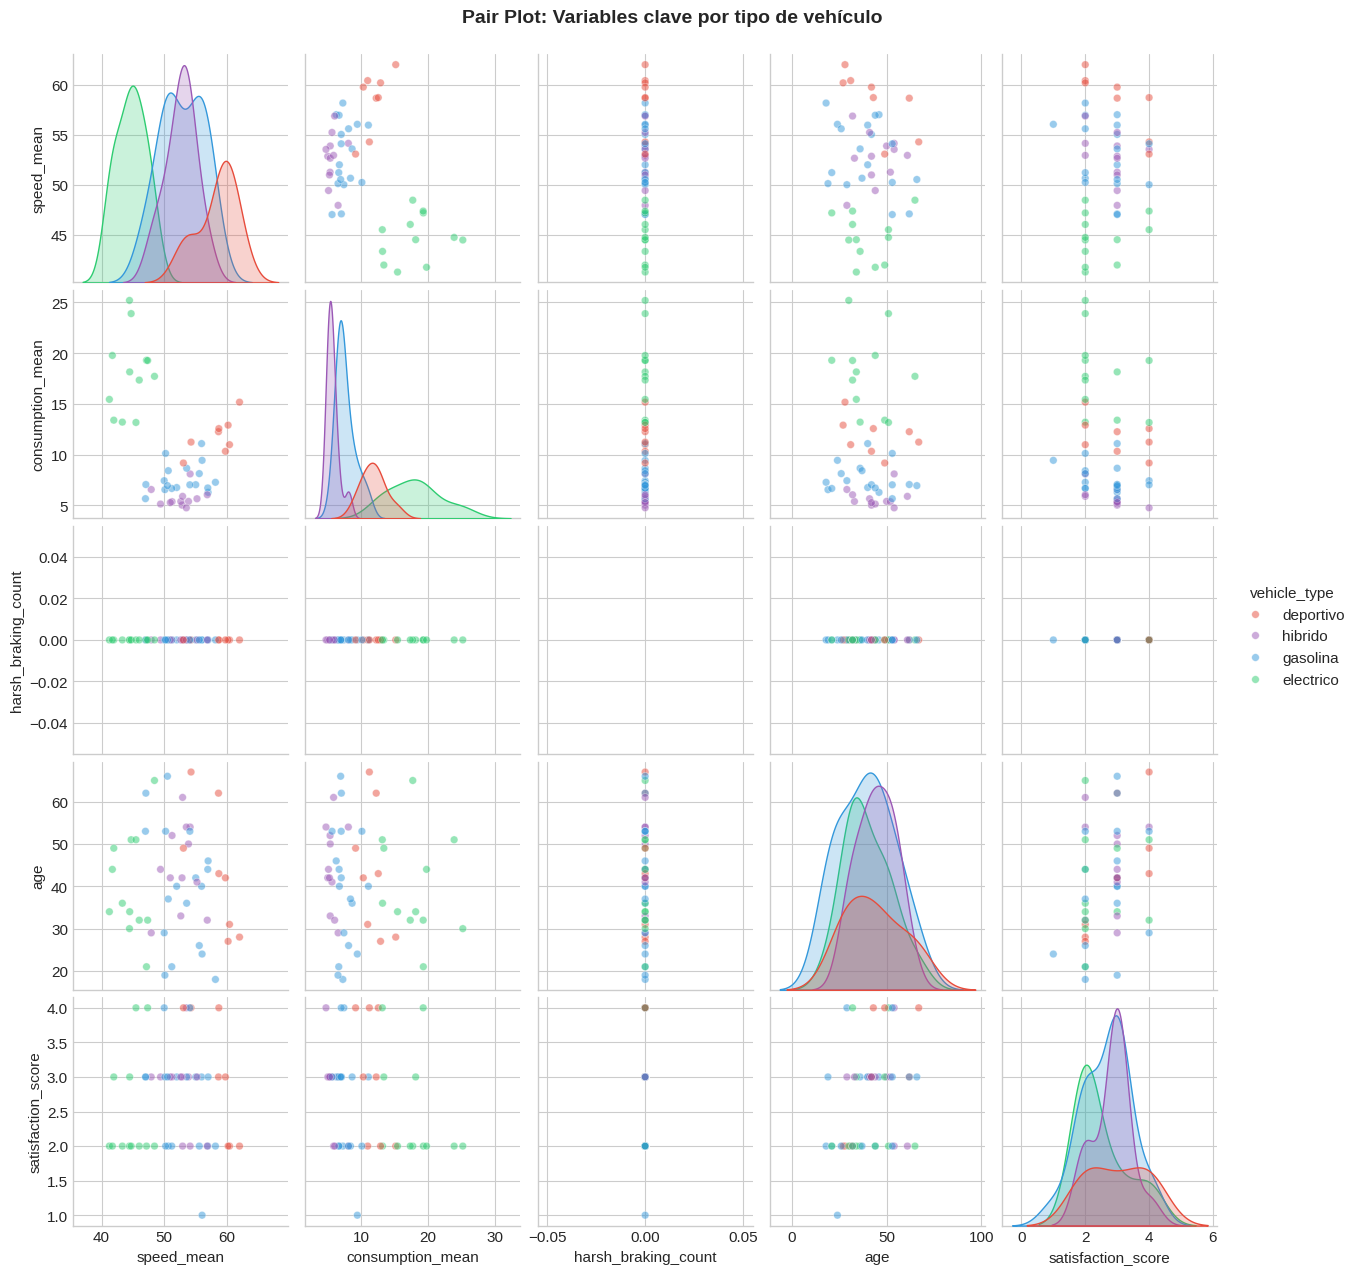

→ El pair plot muestra TODAS las combinaciones de variables de un vistazo
→ Diagonal = distribución individual, fuera de diagonal = scatter entre pares


In [3]:
# Pair plot de variables clave (coloreado por tipo de vehículo)
pair_vars = ['speed_mean', 'consumption_mean', 'harsh_braking_count', 'age', 'satisfaction_score']
pair_data = data[pair_vars + ['vehicle_type']].dropna()

g = sns.pairplot(pair_data, hue='vehicle_type', palette=vtype_colors,
                 diag_kind='kde', plot_kws={'alpha': 0.5, 's': 30, 'edgecolor': 'white'},
                 height=2.5)
g.figure.suptitle('Pair Plot: Variables clave por tipo de vehículo', fontsize=14, fontweight='bold', y=1.02)
plt.show()

print("→ El pair plot muestra TODAS las combinaciones de variables de un vistazo")
print("→ Diagonal = distribución individual, fuera de diagonal = scatter entre pares")

## 3. Box plots agrupados

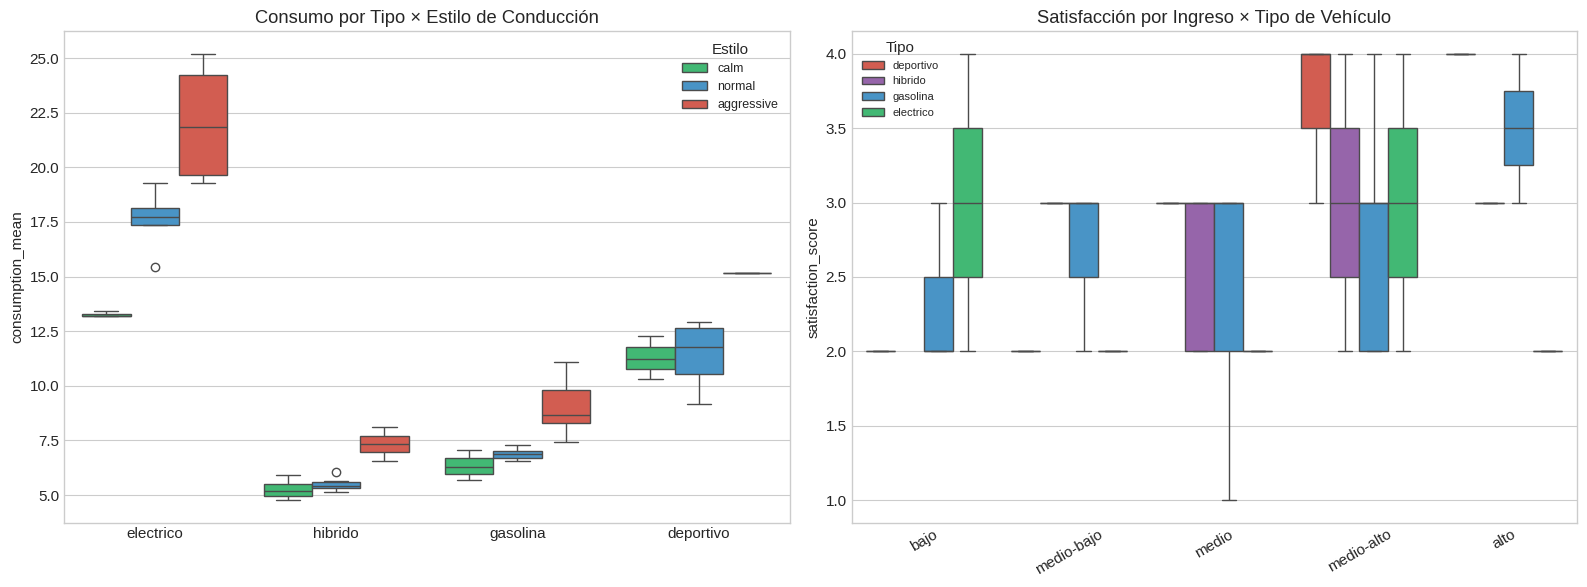

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Consumo por tipo de vehículo Y estilo de conducción
style_palette = {'calm': '#2ecc71', 'normal': '#3498db', 'aggressive': '#e74c3c'}
sns.boxplot(data=data, x='vehicle_type', y='consumption_mean', hue='driving_style',
            ax=axes[0], palette=style_palette,
            order=['electrico', 'hibrido', 'gasolina', 'deportivo'],
            hue_order=['calm', 'normal', 'aggressive'])
axes[0].set_title('Consumo por Tipo × Estilo de Conducción')
axes[0].set_xlabel('')
axes[0].legend(title='Estilo', fontsize=9)

# Satisfacción por ingreso Y tipo
sns.boxplot(data=data, x='income_bracket', y='satisfaction_score', hue='vehicle_type',
            ax=axes[1], palette=vtype_colors,
            order=['bajo', 'medio-bajo', 'medio', 'medio-alto', 'alto'])
axes[1].set_title('Satisfacción por Ingreso × Tipo de Vehículo')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Tipo', fontsize=8)

plt.tight_layout()
plt.show()

## 4. Matriz de correlación completa

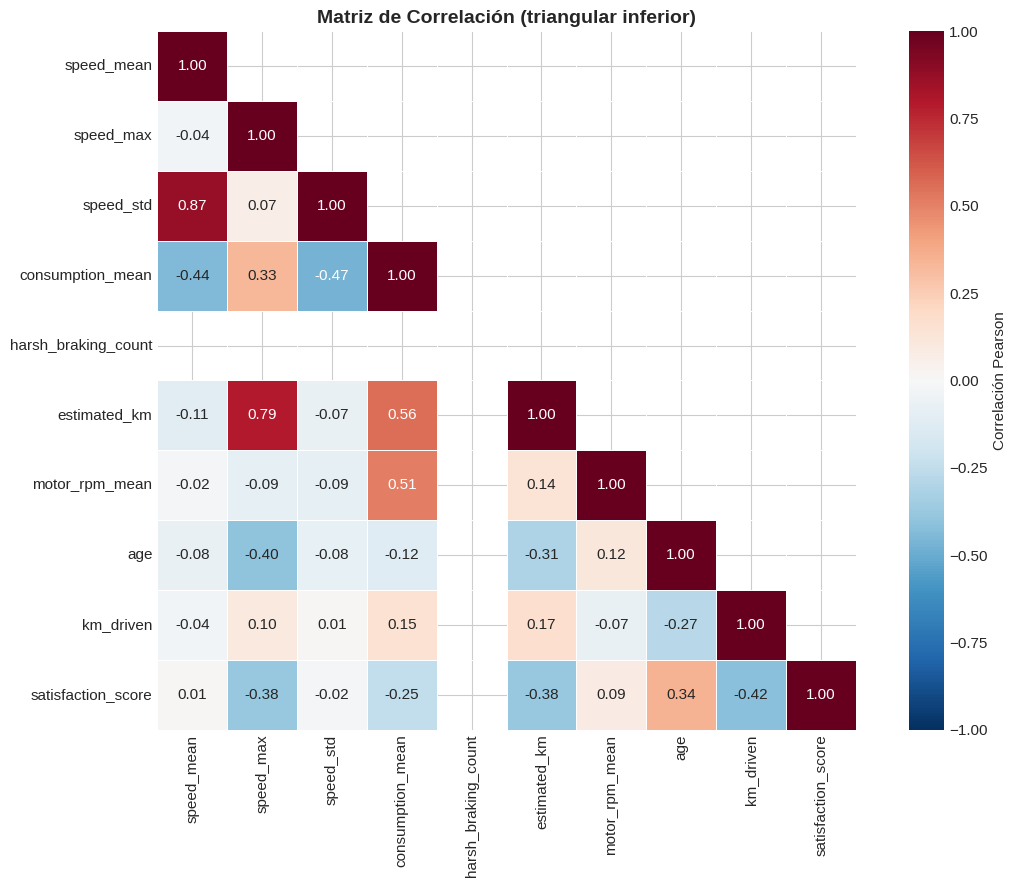

In [5]:
# Seleccionar todas las variables numéricas relevantes
numeric_cols = ['speed_mean', 'speed_max', 'speed_std', 'consumption_mean',
                'harsh_braking_count', 'estimated_km', 'motor_rpm_mean',
                'age', 'km_driven', 'satisfaction_score']
numeric_data = data[numeric_cols].dropna()

corr = numeric_data.corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, square=True,
            linewidths=0.5, cbar_kws={'label': 'Correlación Pearson'})
ax.set_title('Matriz de Correlación (triangular inferior)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

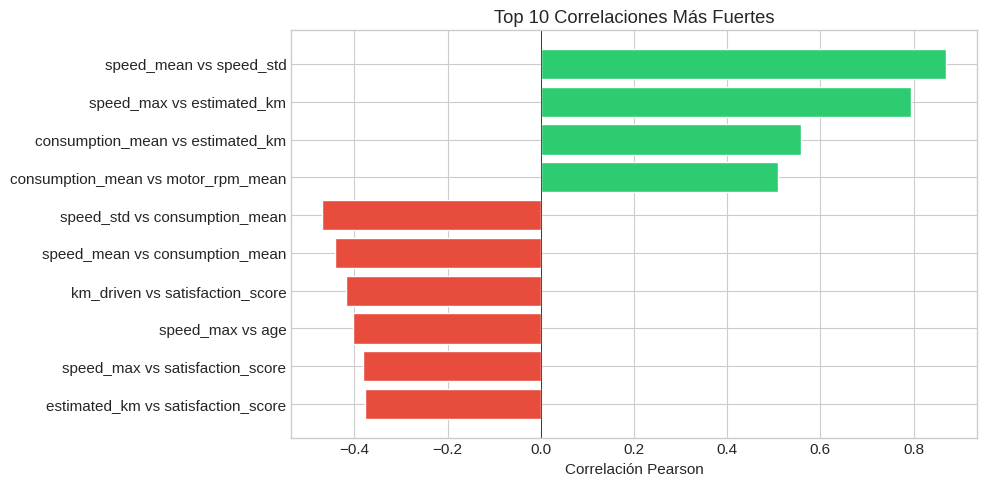

In [6]:
# Top correlaciones (excluyendo diagonal)
corr_pairs = []
for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        corr_pairs.append({
            'var1': corr.columns[i],
            'var2': corr.columns[j],
            'correlation': corr.iloc[i, j],
            'abs_corr': abs(corr.iloc[i, j]),
        })

top_corr = pd.DataFrame(corr_pairs).sort_values('abs_corr', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in top_corr['correlation']]
labels = top_corr['var1'] + ' vs ' + top_corr['var2']
ax.barh(range(len(top_corr)), top_corr['correlation'], color=colors, edgecolor='white')
ax.set_yticks(range(len(top_corr)))
ax.set_yticklabels(labels)
ax.set_xlabel('Correlación Pearson')
ax.set_title('Top 10 Correlaciones Más Fuertes')
ax.axvline(0, color='black', linewidth=0.5)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Resumen

### Respuesta:
> **¿Qué variables están relacionadas?**
>
> Las relaciones más fuertes: velocidad↔consumo (positiva), velocidad↔RPM (positiva),
> variabilidad de velocidad↔frenadas bruscas (conducción agresiva). La edad tiene
> correlación débil con velocidad. La satisfacción se relaciona más con km recorridos
> que con el consumo. Estas relaciones serán la base para modelos predictivos.

### Siguiente:
→ `05_geospatial_visualization.ipynb`: Mapas y patrones geográficos